In [ ]:
from models.conv_ae import *
from tasks.safety_monitor import *
from cd.utils.windows import WindowDataset
from cd.utils.paths import get_root

from sklearn.metrics import confusion_matrix
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
BS = 128

In [3]:
task = SafetyMonitor('hopper', Params(win=70, hor=70))
x_tr, x_te = task.get_train_test()
x_tr = x_tr.astype(np.float32)
x_te = x_te.astype(np.float32)

y_true = task.y_true
x_tr.shape, x_te.shape

Sampled windows from 1000 / 1000 trajectories


((283, 1000, 11), (1000, 70, 11))

In [4]:
ds_tr = WindowDataset(x_tr, window=70, stride=10)
print(f'{len(ds_tr)} and {len(x_te)} test windows w/ {y_true.mean()} fails')

dl_tr = DataLoader(ds_tr, batch_size=BS, shuffle=True)
dl_te = DataLoader(x_te, batch_size=BS)

26602 and 1000 test windows w/ 0.706 fails


In [50]:
model = ConvAE(in_len=x_te.shape[1], in_chan=x_te.shape[2], out_chan=60, latent_dim=30)
sum(p.numel() for p in model.parameters())

112481

In [51]:
opt = torch.optim.Adam(model.parameters(), lr=3e-4)
losses = train(model, dl_tr, opt, epochs=15, device='mps')


Epoch 0: loss=0.1975
Epoch 1: loss=0.0495
Epoch 2: loss=0.0301
Epoch 3: loss=0.0227
Epoch 4: loss=0.0186
Epoch 5: loss=0.0162
Epoch 6: loss=0.0144
Epoch 7: loss=0.0132
Epoch 8: loss=0.0121
Epoch 9: loss=0.0114
Epoch 10: loss=0.0107
Epoch 11: loss=0.0103
Epoch 12: loss=0.0097
Epoch 13: loss=0.0093
Epoch 14: loss=0.0089


Text(0, 0.5, 'MSE')

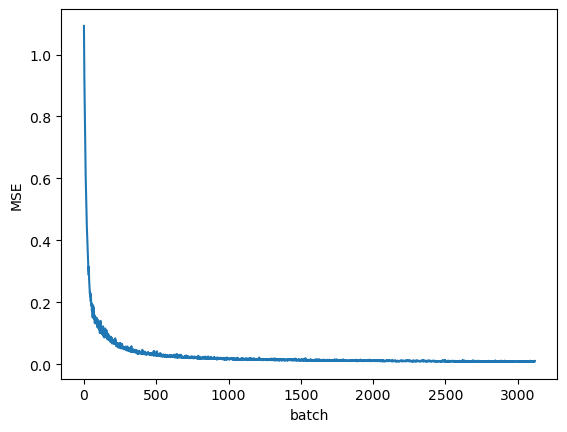

In [52]:
plt.plot(losses)
plt.xlabel('batch')
plt.ylabel('MSE')

Sample 686, comp 9


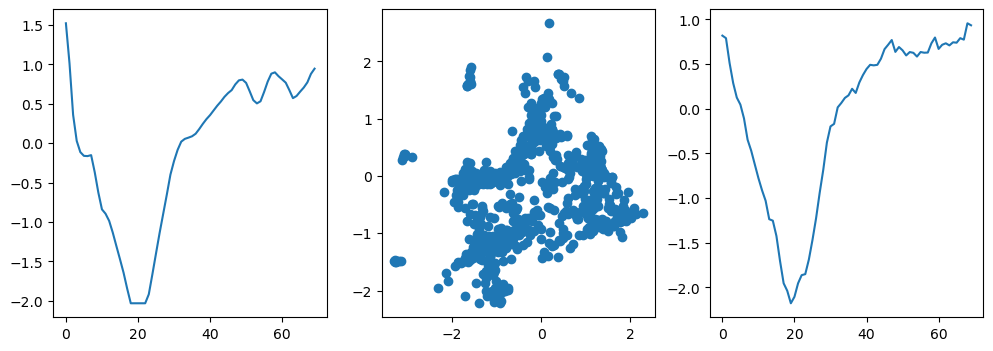

In [53]:
x = torch.concatenate([batch for i, batch in enumerate(dl_tr) if i <= 5])
n = len(x)
xhat, z = model.predict(x)

i = np.random.randint(low=0, high=n)
j = np.random.randint(low=0, high=11)
print(f'Sample {i}, comp {j}')

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].plot(x[i,:,j]);
ax[1].scatter(*z[:,:2].T);
ax[2].plot(xhat[i,:,j]);

True


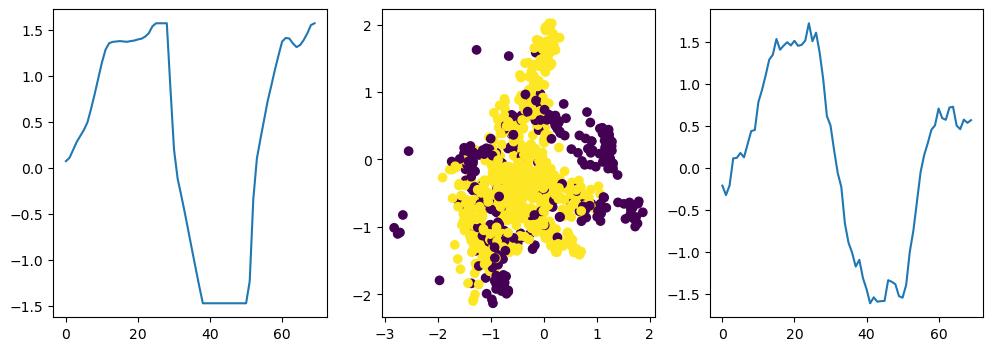

In [54]:
x = torch.concatenate([batch for i, batch in enumerate(dl_te) if i <= 10])
xhat, z = model.predict(x)
n = len(x)

i = np.random.randint(low=0, high=n)
j = np.random.randint(low=0, high=11)

print(y_true[i])

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].plot(x[i,:,j]);
ax[1].scatter(*z[:,:2].T, c=y_true[:n]);
ax[2].plot(xhat[i,:,j]);

In [55]:
# given: dl_tr, dl_te, trained model
def eval_recon_clf(model, dl_tr, dl_te):
    scores_tr = []
    for x in dl_tr:
        with torch.no_grad():
            score = model.get_scores(x)
            scores_tr.append(score.numpy())
    scores_tr = np.concatenate(scores_tr)
    q = np.quantile(scores_tr, q=0.95)

    scores_te = []
    for x in dl_te:
        with torch.no_grad():
            score = model.get_scores(x)
            scores_te.append(score.numpy())
    scores_te = np.concatenate(scores_te)

    y_pred = scores_te > q
    print(100*confusion_matrix(y_true, y_pred, normalize='true'))
    return scores_tr, scores_te, q


In [56]:
s1, s2, q = eval_recon_clf(model, dl_tr, dl_te)

[[  0. 100.]
 [  0. 100.]]


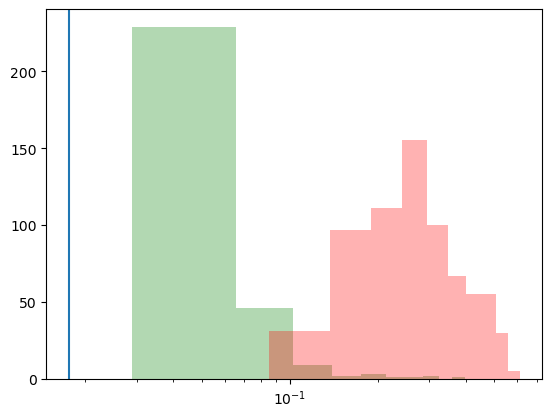

In [57]:
plt.hist(s2[~y_true], color='green', alpha=0.3)
plt.hist(s2[y_true], color='red', alpha=0.3)
plt.axvline(q)
plt.xscale('log')

In [62]:
from sklearn.decomposition import KernelPCA, PCA

u = KernelPCA(n_components=3, kernel='rbf').fit_transform(z)

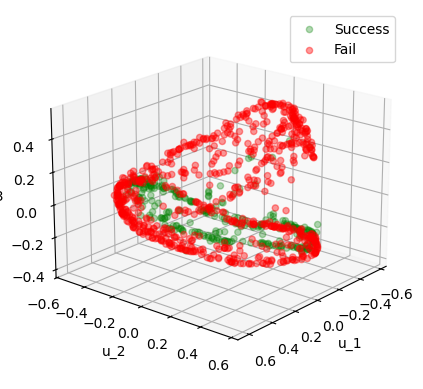

In [74]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(u[y_true==False, 0], u[y_true==False, 1], u[y_true==False, 2], c='green', label='Success', alpha=0.3)
ax.scatter(u[y_true==True, 0], u[y_true==True, 1], u[y_true==True, 2], c='red', label='Fail', alpha=0.4)

ax.set_xlabel('u_1')
ax.set_ylabel('u_2')
ax.set_zlabel('u_3')

ax.view_init(elev=20, azim=40)

ax.legend()
plt.show()